# MVP - Machine Learning & Analytics

**Aluna:** Ana Nery Alves Daniel

**Matrícula:** 4052024002341

**Dataset:** [Microdados da Educação Superior 2023](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-da-educacao-superior) e [Municípios do Ceará segundo Regiões de Planejamento](https://www.ipece.ce.gov.br/regioes-de-planejamento/)


# Descrição do Problema

Concentração de sedes administrativas de instituições de ensino superior (IES) do Ceará somente em poucas regiões do estado, bem como baixo número de docentes em exercício declarados pretos nessas instituições em relação ao número total.


# Objetivo


Realizar levantamento do quantitativo de sedes administrativas de Instituições de Ensino Superior (IES) e do número de docentes autodeclarados pretos nessas instituições nos municípios do Ceará, consolidando a visão desse panorama por Região de Planejamento do estado (1) e, a partir disso, aplicar um modelo de *machine learning* com o intuito de agrupar as Regiões de Planejamento do Ceará de acordo com suas semelhanças estruturais e institucionais, de modo a contribuir para a ampliação de políticas públicas melhor direcionadas no território cearense.

**Observação:** Este MVP abrangerá o conteúdo do MVP da Sprint Análise de Dados e Boas Práticas e, também, da **Sprint Machine Learning & Analitics**, havendo maior foco do conteúdo desta última **a partir da seção Modelagem e Treinamento** deste trabalho.

# Recorte

O foco deste levantamento são as instituiçõe-sede administrativas de ensino do estado do Ceará, e não inclui unidades menores dessas instituições (polos) em razão desses dados não terem sido disponibilizados pelo Inep. Portanto, considera-se IES neste levantamento somente as sedes administrativas dessas instituições.

<br>
(1) Região de Planejamento do estado do Ceará: Divisões territoriais criadas para organizar o planejamento e a implementação de políticas públicas. Classificação do Instituto de Pesquisa e Estratégia Econômica do Ceará - IPECE.

# Hipóteses do Problema


*   Má distribuição de instituições de ensino superior no estado do Ceará, havendo alta concentração na região de planejamento Grande Fortaleza em detrimento das demais regiões do estado.

* Baixo número de docentes autodeclarados pretos nas instituições de ensino superior do Ceará em relação ao quantitativo total desses professores.


# Tipo de Problema

O problema explorado neste dataset é classificado como de **aprendizado não supervisionado**, uma vez que não há rótulos ou categorias pré-definidas nos dados, o que impede a aplicação direta de técnicas de classificação supervisionada. Por esse motivo, será utilizada uma abordagem de machine learning baseada em **clusterização**, com o objetivo de identificar agrupamentos naturais e padrões ocultos nos dados.

#COLETA DE DADOS

## Seleção de Dados

O dataset deste trabalho é composto por duas fontes de dados. A primeira fonte lista um conjunto de sedes de instituições de ensino superior no Brasil, obtidas do [Censo Inep de 2023](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-da-educacao-superior), e a segunda fonte lista os municípios do estado do Ceará por região de planejamento administrativo, sendo esse obtido do [Ipece](https://www.ipece.ce.gov.br/regioes-de-planejamento/).

Optou-se por filtrar e analisar somente os dados do estado do Ceará em razão da facilidade de acesso à lista de regiões de planejamento desse estado, o que não ocorreu com as demais regiões do país. Vale ressaltar que o Ipece fornece a lista de municípios classificada por região de planejamento, mas não fornece nenhum dos critérios utilizados para essa classificação.

In [ ]:
import pandas as pd

# Carregar o dataset
url_ies = 'https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/Sprint-AnaliseDadosEBoasPraticas/datasets/MICRODADOS_ED_SUP_IES_2023.CSV%20-%20BRUTOS.csv'
df_ies = pd.read_csv(url_ies)

# Filtrar os registros onde SG_UF_IES é igual a 'CE'
df_ce = df_ies[df_ies['SG_UF_IES'] == 'CE']

# Contar a quantidade de valores únicos na coluna SG_IES
quantidade_unique_SG_IES = df_ce['SG_IES'].nunique()

print(f'A quantidade de SG_IES não repetidos na UF CE é: {quantidade_unique_SG_IES}')

A quantidade de SG_IES não repetidos na UF CE é: 75


In [ ]:
import pandas as pd

# Carregar o dataset a partir da URL
url_regioes = "https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/Sprint-AnaliseDadosEBoasPraticas/datasets/Lista_Regioes_Planejamento_Ceara.csv"
df_regioes = pd.read_csv(url_regioes)

# Remover espaços em branco nas colunas, se houver
df_regioes.columns = df_regioes.columns.str.strip()

# Verificar se existe alguma coluna com nome parecido com 'Regiao'
print(df_regioes.columns)

# Agora, contar o número de regiões distintas
if 'Regiao' in df_regioes.columns:
    num_regioes = df_regioes['Regiao'].nunique()
    print(f'\nO número de regiões distintas é: {num_regioes}')
else:
    print("\nA coluna 'Regiao' não foi encontrada no DataFrame.")

Index(['Código do município (IBGE)', 'Nome do município', 'Regiao'], dtype='object')

O número de regiões distintas é: 14


In [ ]:
# Contar o número de municípios únicos na coluna 'Nome do município'
num_municipios = df_regioes['Nome do município'].nunique()

print(f'O número de municípios é: {num_municipios}')

O número de municípios é: 184


## Atributos do Dataset

**Dataset Instituições de Ensino Superior (IES)**

Este dataset contém 75 sedes de instituições de ensino superior no Ceará conforme consulta acima. Os atributos dessas instituições utilizados nesta pesquisa estão descritos abaixo:

| Nome da coluna | Tipo | Tamanho | Descrição |
| -------- | ----- | ----- | ----------- |
| CO_IES | Num | 8 | Código único de identificação da IES |
| NO_MUNICIPIO_IES | Char | 150 | Nome do Município da sede administrativa ou reitoria da IES
| NO_IES | Char | 200 | Nome da IES
| SG_IES |Char | 20 | Sigla da IES
| SG_UF_IES |Char | 2 | Sigla da Unidade da Federação da sede administrativa ou reitoria da IES
| CO_MUNICIPIO_IES | Num | 7 | Código do município da sede administrativa da IES
| TIPO_REDE | Char | 7 | Tipo de rede de ensino (1. pública /2.privada)
| QT_DOC_EXE | Num | 8 | Quantidade total de docentes em exercício
| QT_DOC_EX_PRETA | Num | 8 | Quantidade de docentes em exercício - Cor/Raça preta

<br>

**Dataset Regiões de Planejamento do Ceará**

Este dataset contém 184 municípios divididos em 14 Regiões de Planejamento. Os atributos dessas instituições utilizados nesta pesquisa estão descritos abaixo:

| Nome da coluna | Tipo | Tamanho | Descrição |
| -------- | ----- | ----- | ----------- |
| CO_MUNICIPIO | Num| 7 | Código do município da sede administrativa da IES |
| Nome do município | Char | 150 | Nome do Município da sede administrativa ou reitoria da IES
| Região de Planejamento | Char | 100 | Nome da região de planejamento do Ceará.



## Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.stats import mode
from adjustText import adjust_text

In [ ]:
pip install adjustText

In [ ]:
# carregamento do dataset instituições de ensino superior (ies)
url_ies = 'https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/modelagem%20vers%C3%A3o%203/MICRODADOS_ED_SUP_IES_2023.CSV%20-%20BRUTOS.csv'


In [ ]:
# primeiras linhas do dataframe ies
df_ies.head()

,NU_ANO_CENSO,NO_REGIAO_IES,CO_REGIAO_IES,NO_UF_IES,SG_UF_IES,CO_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,IN_CAPITAL_IES,NO_MESORREGIAO_IES,CO_MESORREGIAO_IES,NO_MICRORREGIAO_IES,CO_MICRORREGIAO_IES,TP_ORGANIZACAO_ACADEMICA,TP_REDE,TP_CATEGORIA_ADMINISTRATIVA,IN_COMUNITARIA,IN_CONFESSIONAL,NO_MANTENEDORA,CO_MANTENEDORA,CO_IES,NO_IES,SG_IES,DS_ENDERECO_IES,DS_NUMERO_ENDERECO_IES,DS_COMPLEMENTO_ENDERECO_IES,NO_BAIRRO_IES,NU_CEP_IES,QT_TEC_TOTAL,QT_TEC_FUNDAMENTAL_INCOMP_FEM,QT_TEC_FUNDAMENTAL_INCOMP_MASC,QT_TEC_FUNDAMENTAL_COMP_FEM,QT_TEC_FUNDAMENTAL_COMP_MASC,QT_TEC_MEDIO_FEM,QT_TEC_MEDIO_MASC,QT_TEC_SUPERIOR_FEM,QT_TEC_SUPERIOR_MASC,QT_TEC_ESPECIALIZACAO_FEM,QT_TEC_ESPECIALIZACAO_MASC,QT_TEC_MESTRADO_FEM,QT_TEC_MESTRADO_MASC,QT_TEC_DOUTORADO_FEM,QT_TEC_DOUTORADO_MASC,IN_ACESSO_PORTAL_CAPES,IN_ACESSO_OUTRAS_BASES,IN_ASSINA_OUTRA_BASE,IN_REPOSITORIO_INSTITUCIONAL,IN_BUSCA_INTEGRADA,IN_SERVICO_INTERNET,IN_PARTICIPA_REDE_SOCIAL,IN_CATALOGO_ONLINE,QT_PERIODICO_ELETRONICO,QT_LIVRO_ELETRONICO,QT_DOC_TOTAL,QT_DOC_EXE,QT_DOC_EX_FEMI,QT_DOC_EX_MASC,QT_DOC_EX_SEM_GRAD,QT_DOC_EX_GRAD,QT_DOC_EX_ESP,QT_DOC_EX_MEST,QT_DOC_EX_DOUT,QT_DOC_EX_INT,QT_DOC_EX_INT_DE,QT_DOC_EX_INT_SEM_DE,QT_DOC_EX_PARC,QT_DOC_EX_HOR,QT_DOC_EX_0_29,QT_DOC_EX_30_34,QT_DOC_EX_35_39,QT_DOC_EX_40_44,QT_DOC_EX_45_49,QT_DOC_EX_50_54,QT_DOC_EX_55_59,QT_DOC_EX_60_MAIS,QT_DOC_EX_BRANCA,QT_DOC_EX_PRETA,QT_DOC_EX_PARDA,QT_DOC_EX_AMARELA,QT_DOC_EX_INDIGENA,QT_DOC_EX_COR_ND,QT_DOC_EX_BRA,QT_DOC_EX_EST,QT_DOC_EX_COM_DEFICIENCIA
0,2023,Centro-Oeste,5,Mato Grosso,MT,51,Cuiabá,5103403,1,Centro-Sul Mato-grossense,4,Cuiabá,17,1,1,1,0,0,FUNDACAO UNIVERSIDADE FEDERAL DE MATO GROSSO,1,1,UNIVERSIDADE FEDERAL DE MATO GROSSO,UFMT,Avenida Fernando Correa da Costa,2367,Cidade Universitária,Boa Esperança,78060900.0,1335,2,15,1,11,27,59,87,106,331,327,172,107,55,35,1,0,1,1,1,1,1,1,50,50,1742,1588,764,824,0,83,51,191,1263,1537,1276,261,51,0,44,144,298,318,276,197,136,175,1003,85,454,38,6,2,1559,29,12
1,2023,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,1,Distrito Federal,1,Brasília,1,1,1,1,0,0,FUNDACAO UNIVERSIDADE DE BRASILIA,2,2,UNIVERSIDADE DE BRASÍLIA,UNB,Campus Universitário Darcy Ribeiro,s/n,-,Asa Norte,70910900.0,2906,0,0,2,24,100,118,177,225,746,704,386,265,93,66,1,0,1,1,1,1,1,1,441,13095,3120,2801,1288,1513,0,9,18,224,2550,2647,2323,324,154,0,44,146,335,500,482,369,377,548,1958,109,625,66,11,32,2669,132,10
2,2023,Nordeste,2,Sergipe,SE,28,São Cristóvão,2806701,0,Leste Sergipano,3,Aracaju,11,1,1,1,0,0,FUNDACAO UNIVERSIDADE FEDERAL DE SERGIPE,3,3,UNIVERSIDADE FEDERAL DE SERGIPE,UFS,Avenida Marechal Rondon,s/n,-,Jardim Rosa Elze,49100000.0,1769,0,23,8,12,211,137,269,188,275,187,219,137,65,38,1,0,1,1,1,1,1,1,40939,320055,1820,1768,846,922,0,100,2,210,1456,1652,1441,211,115,1,36,127,258,359,331,250,202,205,242,36,295,11,1,1183,1739,29,5
3,2023,Norte,1,Amazonas,AM,13,Manaus,1302603,1,Centro Amazonense,3,Manaus,7,1,1,1,0,0,FUNDACAO UNIVERSIDADE DO AMAZONAS,4,4,UNIVERSIDADE FEDERAL DO AMAZONAS,UFAM,Av. Rodrigo Otávio,6200,Unidade Sede,Coroado II,69077000.0,1931,9,54,5,40,116,201,225,258,389,266,169,134,35,30,1,0,1,1,0,1,1,1,41,6272,2051,2048,934,1114,0,94,200,537,1217,1868,1466,402,180,0,112,217,328,344,295,248,249,255,167,22,1684,6,2,167,2048,0,6
4,2023,Nordeste,2,Piauí,PI,22,Teresina,2211001,1,Centro-Norte Piauiense,2,Teresina,3,1,1,1,0,0,FUNDACAO UNIVERSIDADE FEDERAL DO PIAUI,14054,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,Campus Universitário Ministro Petrônio Portela,s/n,SG - 07,Ininga,64049550.0,2243,128,223,58,82,340,508,51,71,258,211,135,99,44,35,1,0,1,1,1,1,1,1,0,0,1693,1469,710,759,2,5,70,250,1142,1374,1174,200,95,0,22,134,231,304,228,144,163,243,164,41,257,3,1,1003,1469,0,0


In [ ]:
# carregamento do dataset das regiões de planejamento do Ceará
url_regioes = 'https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/modelagem%20vers%C3%A3o%203/Lista_Regioes_Planejamento_Ceara.csv'


In [ ]:
# primeiras linhas do dataframe regiões de planejamento
df_regioes.head()

,Código do município (IBGE),Nome do município,Regiao
0,2300101,Abaiara,Cariri
1,2300150,Acarape,Maciço de Baturité
2,2300200,Acaraú,Litoral Norte
3,2300309,Acopiara,Centro Sul
4,2300408,Aiuaba,Sertão dos Inhamuns


# ANÁLISE DE DADOS

Esta etapa traz uma visão geral dos dados obtidos dos dois datasets que irão compor a análise deste trabalho (Instituições de Ensino Superior e Regiões de Planejamento do Ceará) a partir dos quais será realizada filtragem dos dados, bem como outros tratamentos necessários para obter as informações indispensáveis para atingir o objetivo desta pesquisa.

## Total e Tipo das Instâncias

**Dataset Instituições de Ensino Superior**

Este dataset possui 2580 instâncias (observações) nas quais existem variáveis do tipo categórica, como as que definem o nome do município, estado e das sedes das instituições de ensino superior (IES); e numérica do tipo inteiro, como as que quantificam o total de docentes, de docentes por cor, bem como a variável ano.

**Dataset Regiões de Planejamento do Ceará**

Este dataset possui 184 instâncias (observações) somente com variáveis categóricas: nome do município, nome da região e código do município.




In [ ]:
# Obter o tipo de cada coluna Instituições de Ensino Superior
tipos = df_ies.dtypes

# Obter o total de instâncias (linhas) Instituições de Ensino Superior
total_instancias = len(df_ies)

print("Tipos de cada coluna:\n", tipos)
print("\nTotal de instâncias (linhas):", total_instancias)

Tipos de cada coluna:
 NU_ANO_CENSO                  int64
NO_REGIAO_IES                object
CO_REGIAO_IES                 int64
NO_UF_IES                    object
SG_UF_IES                    object
                              ...  
QT_DOC_EX_INDIGENA            int64
QT_DOC_EX_COR_ND              int64
QT_DOC_EX_BRA                 int64
QT_DOC_EX_EST                 int64
QT_DOC_EX_COM_DEFICIENCIA     int64
Length: 84, dtype: object

Total de instâncias (linhas): 2580


In [ ]:
# Obter o tipo de cada coluna Regiões de Planejamento do Ceará
tipos = df_regioes.dtypes

# Obter o total de instâncias (linhas) Regiões de Planejamento do Ceará
total_instancias = len(df_regioes)

print("Tipos de cada coluna:\n", tipos)
print("\nTotal de instâncias (linhas):", total_instancias)

Tipos de cada coluna:
 Código do município (IBGE)     int64
Nome do município             object
Regiao                        object
dtype: object

Total de instâncias (linhas): 184


## Delimitando o dataset para Instituições de Ensino Superior (IES) somente do estado do Ceará

Na seção a seguir será realizada a filtragem do dataset das Instituições de Ensino Superior (IES) para retornar somente as instituições do estado do Ceará, substituindo os código 1 e 2 da coluna TP Rede pelo seu significado, pública e privada, respectivamente.

In [ ]:
# 1. Lista de colunas desejadas
colunas = [
    'CO_IES',
    'NO_IES',
    'SG_IES',
    'SG_UF_IES',
    'NO_MUNICIPIO_IES',
    'CO_MUNICIPIO_IES',
    'TP_REDE',
    'QT_DOC_EXE',
    'QT_DOC_EX_PRETA'
]

df = df_ies[colunas]

# 2. Filtrar linhas onde SG_UF_IES == 'CE'
df_ce = df[df['SG_UF_IES'] == 'CE'].copy()

# 3. Substituir valores da coluna TP_REDE para textos descritivos
df_ce['TP_REDE'] = df_ce['TP_REDE'].map({1: 'pública', 2: 'privada'})

# (Removido o filtro que mantinha apenas instituições públicas)

# 4. Organizar display como tabela
df_ce.reset_index(drop=True, inplace=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_ce.head()

,CO_IES,NO_IES,SG_IES,SG_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,TP_REDE,QT_DOC_EXE,QT_DOC_EX_PRETA
0,29,UNIVERSIDADE ESTADUAL DO CEARÁ,UECE,CE,Fortaleza,2304400,pública,1138,16
1,95,UNIVERSIDADE ESTADUAL VALE DO ACARAÚ,UVA,CE,Sobral,2312908,pública,508,33
2,555,UNIVERSIDADE DE FORTALEZA,UNIFOR,CE,Fortaleza,2304400,privada,960,13
3,583,UNIVERSIDADE FEDERAL DO CEARÁ,UFC,CE,Fortaleza,2304400,pública,2332,76
4,746,UNIVERSIDADE REGIONAL DO CARIRI,URCA,CE,Crato,2304202,pública,552,10


## Identificando se há **valores ausentes** no dataset Instituições de Ensino Superior no Ceará (df_ce)


In [ ]:
# Verificar colunas com valores ausentes em df_ce
colunas_com_ausentes = df_ce.columns[df_ce.isnull().any()]

# Exibir colunas com valores ausentes e a quantidade de valores faltantes
print("Colunas com valores ausentes em df_ce:")
print(df_ce[colunas_com_ausentes].isnull().sum())

Colunas com valores ausentes em df_ce:
SG_IES    22
dtype: int64


**Análise**: A consulta acima identificou 22 valores ausentes na coluna SG_IES. Possivelmente, ou essas IES não têm sigla, ou simplesmente esse valor não foi informado. Assim, como tratamento, o dataframe irá substituir os valores ausentes por "Não informada", a partir do comando a seguir:

In [ ]:
# Substituir os NaNs da coluna SG_IES por "Não informada"
df_ce['SG_IES'] = df_ce['SG_IES'].fillna('Não informada')

# Exibir as 20 primeiras linhas do DataFrame
df_ce.head(10)

,CO_IES,NO_IES,SG_IES,SG_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,TP_REDE,QT_DOC_EXE,QT_DOC_EX_PRETA
0,29,UNIVERSIDADE ESTADUAL DO CEARÁ,UECE,CE,Fortaleza,2304400,pública,1138,16
1,95,UNIVERSIDADE ESTADUAL VALE DO ACARAÚ,UVA,CE,Sobral,2312908,pública,508,33
2,555,UNIVERSIDADE DE FORTALEZA,UNIFOR,CE,Fortaleza,2304400,privada,960,13
3,583,UNIVERSIDADE FEDERAL DO CEARÁ,UFC,CE,Fortaleza,2304400,pública,2332,76
4,746,UNIVERSIDADE REGIONAL DO CARIRI,URCA,CE,Crato,2304202,pública,552,10
5,1059,Faculdade Multiversa de Fortaleza,Não informada,CE,Fortaleza,2304400,privada,14,0
6,1107,Centro Universitário Estácio do Ceará,Estácio Ceará,CE,Fortaleza,2304400,privada,564,12
7,1191,INSTITUTO DE ENSINO SUPERIOR DE FORTALEZA,IESF,CE,Fortaleza,2304400,privada,12,0
8,1350,Centro Universitário Multiversa do Jaguaribe- ...,UNIJAGUARIBE,CE,Aracati,2301109,privada,90,3
9,1425,Faculdade Evoluir,FAEV,CE,Fortaleza,2304400,privada,20,0


## Identificando se há **valores ausentes** no dataset Regiões de Planejamento do Ceará (df_regioes)

In [ ]:
# Verificar colunas com valores ausentes em df_ce
colunas_com_ausentes = df_regioes.columns[df_regioes.isnull().any()]

# Exibir colunas com valores ausentes e a quantidade de valores faltantes
print("Colunas com valores ausentes em df_regioes:")
print(df_regioes[colunas_com_ausentes].isnull().sum())

Colunas com valores ausentes em df_regioes:
Series([], dtype: float64)


**Análise:** Conforme a consulta acima, **não** foram identificados valores ausentes no dataset Regiões de Planejamento.

## Identificando se há **valores inconsistentes ou outliers** no dataset Instituições de Ensino Superior no Ceará (df_ce)

In [ ]:
# Função que detecta outliers e explica a faixa central (Q1 a Q3)
def detectar_outliers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Criar nova coluna booleana com True para outlier
    nome_coluna_outlier = f"{coluna}_outlier"
    df[nome_coluna_outlier] = ~df[coluna].between(limite_inferior, limite_superior, inclusive='both')

    # Mensagem explicativa
    print(f"\nColuna: {coluna}")
    print(f"  - Q1 (1º quartil): {Q1:.2f}")
    print(f"  - Q3 (3º quartil): {Q3:.2f}")
    print(f"  - Intervalo Interquartil (IQR): {IQR:.2f}")
    print(f"  - Faixa central esperada (sem outliers): de {limite_inferior:.2f} até {limite_superior:.2f}")

    total_outliers = df[nome_coluna_outlier].sum()
    if total_outliers > 0:
        print(f"  - Outliers detectados: {total_outliers} valor(es) fora da faixa")
    else:
        print("  - Nenhum outlier detectado.")

# Colunas a serem analisadas
colunas_para_analisar = ['QT_DOC_EXE', 'QT_DOC_EX_PRETA']

# Aplicar a função para cada coluna
for coluna in colunas_para_analisar:
    detectar_outliers_iqr(df_ce, coluna)

# Verificar valores negativos
for coluna in colunas_para_analisar:
    negativos = (df_ce[coluna] < 0).sum()
    if negativos > 0:
        print(f"\n Valores negativos detectados na coluna '{coluna}': {negativos}")
    else:
        print(f"\n Nenhum valor negativo detectado na coluna '{coluna}'.")

# Remover colunas _outlier não desejadas
colunas_validas = ['QT_DOC_EXE_outlier', 'QT_DOC_EX_PRETA_outlier']
colunas_a_remover = [col for col in df_ce.columns if col.endswith('_outlier') and col not in colunas_validas]
df_ce.drop(columns=colunas_a_remover, inplace=True)

# Exibir as 10 primeiras linhas
df_ce.head(10)



Coluna: QT_DOC_EXE
  - Q1 (1º quartil): 14.00
  - Q3 (3º quartil): 92.00
  - Intervalo Interquartil (IQR): 78.00
  - Faixa central esperada (sem outliers): de -103.00 até 209.00
  - Outliers detectados: 14 valor(es) fora da faixa

Coluna: QT_DOC_EX_PRETA
  - Q1 (1º quartil): 0.00
  - Q3 (3º quartil): 2.00
  - Intervalo Interquartil (IQR): 2.00
  - Faixa central esperada (sem outliers): de -3.00 até 5.00
  - Outliers detectados: 14 valor(es) fora da faixa

 Nenhum valor negativo detectado na coluna 'QT_DOC_EXE'.

 Nenhum valor negativo detectado na coluna 'QT_DOC_EX_PRETA'.


,CO_IES,NO_IES,SG_IES,SG_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,TP_REDE,QT_DOC_EXE,QT_DOC_EX_PRETA,QT_DOC_EXE_outlier,QT_DOC_EX_PRETA_outlier
0,29,UNIVERSIDADE ESTADUAL DO CEARÁ,UECE,CE,Fortaleza,2304400,pública,1138,16,True,True
1,95,UNIVERSIDADE ESTADUAL VALE DO ACARAÚ,UVA,CE,Sobral,2312908,pública,508,33,True,True
2,555,UNIVERSIDADE DE FORTALEZA,UNIFOR,CE,Fortaleza,2304400,privada,960,13,True,True
3,583,UNIVERSIDADE FEDERAL DO CEARÁ,UFC,CE,Fortaleza,2304400,pública,2332,76,True,True
4,746,UNIVERSIDADE REGIONAL DO CARIRI,URCA,CE,Crato,2304202,pública,552,10,True,True
5,1059,Faculdade Multiversa de Fortaleza,Não informada,CE,Fortaleza,2304400,privada,14,0,False,False
6,1107,Centro Universitário Estácio do Ceará,Estácio Ceará,CE,Fortaleza,2304400,privada,564,12,True,True
7,1191,INSTITUTO DE ENSINO SUPERIOR DE FORTALEZA,IESF,CE,Fortaleza,2304400,privada,12,0,False,False
8,1350,Centro Universitário Multiversa do Jaguaribe- ...,UNIJAGUARIBE,CE,Aracati,2301109,privada,90,3,False,False
9,1425,Faculdade Evoluir,FAEV,CE,Fortaleza,2304400,privada,20,0,False,False


**Análise:** Conforme consulta acima, para facilitar a identificação dos outliers, foram criadas duas colunas a mais onde, para cada linha do dataframe, os dados considerados outliers apresentam valor "true" e os que não são valor "false". Foi analisada a existência de outliers somente para as colunas QT_DOC_EX e QT_DOC_EX_PRETA, únicas que são numéricas. As demais são códigos.

O resultado apontou a existência de 14 outliers na quantidade total de docentes em exercício (QT_DOC_EXE) e 14 outliers na quantidade de docentes declarados pretos (QT_DOC_EX_PRETA).

Apesar de discrepantes, os outliers são valores reais e estão corretos, por isso, é importante exibi-los para evidenciar a discrepância na distribuição de docentes entre os municípios.

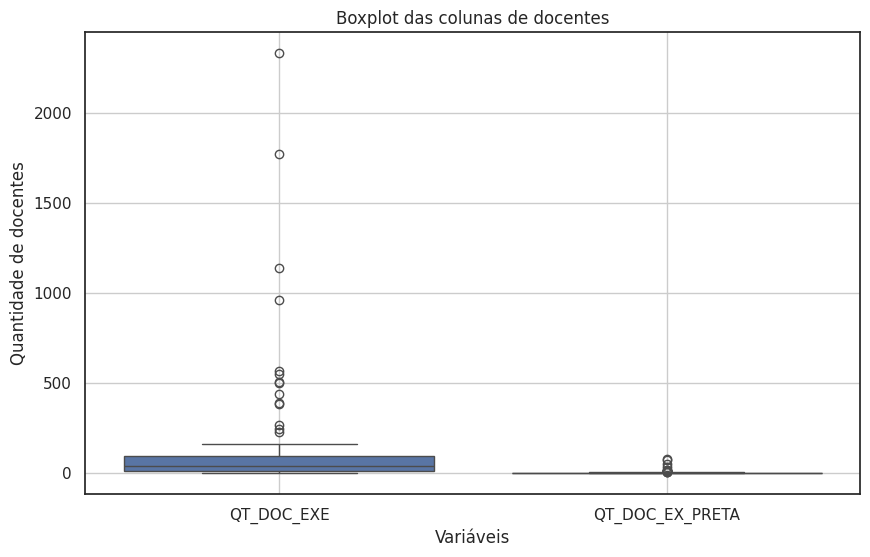

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ce[colunas_para_analisar])
plt.title("Boxplot das colunas de docentes")
plt.ylabel("Quantidade de docentes")
plt.xlabel("Variáveis")
plt.grid(True)
plt.show()


**Análise do gráfico**

O gráfico Boxplot evidencia os outliers identificados na consulta anterior. Pela figura, é possível observarmos vários outliers bem acima da faixa central esperada exibida na consulta anterior, cujo válor máximo seria 209 para a quantidade de docentes em exercício (QT_DOC_EXE), sendo o maior deles valor superior a 2000.Já os outliers referentes à quantidade de docentes em exercício declarados pretos (QT_DOC_EX_PRETA) também rigistrou outliers, porém com valores mais próximos à faixa central, com máximo até 5.

## Novas Variáveis Geradas - Quantitativos por Município (df_ies_docentes_municipio_regiao)

A partir dos datasets df_ce (lista de instituições e docentes do Ceará) e df_regiao (lista de regiões de planejamento do Ceará), será feito abaixo um merge desses datasest, criando o dataset df_ies_docentes_municipio_regiao. Essa consulta é interessante para dar uma visão do número de IES e docentes total e na cor preta em cada município, indentificando, inclusive, os municípios com 0 instituição e 0 docente, se houver. Assim, serão geradas novas variáveis:


**QTD_IES_MUNICIPIO:** Quantidade de instituições de ensino superior no município.

**QTD_DOC_EXE_MUNICIPIO:** Quantidade de docentes em exercício das instituições de ensino superior no município.

**QTD_DOC_EXE_PRETA_MUNICIPIO:** Quantidade de docentes em exercício declarados pretos nas instituições de ensino superior no município.

In [ ]:
# ================================
# Passo 1: Agrupar dados por município (df_ce)
# ================================
df_agrupado = df_ce.groupby('CO_MUNICIPIO_IES').agg(
    QTD_IES_MUNICIPIO=('NO_IES', 'nunique'),
    QTD_DOC_EXE_MUNICIPIO=('QT_DOC_EXE', 'sum'),
    QTD_DOC_EXE_PRETA_MUNICIPIO=('QT_DOC_EX_PRETA', 'sum')
).reset_index()

# ================================
# Passo 2: Preparar df_regiao (renomear colunas para facilitar merge)
# ================================
df_regioes_renomeado = df_regioes.rename(columns={
    'Código do município (IBGE)': 'CO_MUNICIPIO_IES',
    'Nome do município': 'NO_MUNICIPIO_IES'
})

# ================================
# Passo 3: Realizar o merge (left join para manter todos os municípios)
# ================================
df_ies_docentes_municipio_regiao = df_regioes_renomeado.merge(
    df_agrupado,
    on='CO_MUNICIPIO_IES',
    how='left'
)

# ================================
# Passo 4: Substituir NaN por 0 e converter para inteiro
# ================================
colunas_qtd = ['QTD_IES_MUNICIPIO', 'QTD_DOC_EXE_MUNICIPIO', 'QTD_DOC_EXE_PRETA_MUNICIPIO']

df_ies_docentes_municipio_regiao[colunas_qtd] = df_ies_docentes_municipio_regiao[colunas_qtd].fillna(0).astype(int)

# Passo 5: Mover a coluna 'Regiao' para o final
# ================================
colunas = [col for col in df_ies_docentes_municipio_regiao.columns if col != 'Regiao'] + ['Regiao']
df_ies_docentes_municipio_regiao = df_ies_docentes_municipio_regiao[colunas]

# ================================
# Exibir as 10 primeiras linhas
# ================================
df_ies_docentes_municipio_regiao.head(184)



,CO_MUNICIPIO_IES,NO_MUNICIPIO_IES,QTD_IES_MUNICIPIO,QTD_DOC_EXE_MUNICIPIO,QTD_DOC_EXE_PRETA_MUNICIPIO,Regiao
0,2300101,Abaiara,0,0,0,Cariri
1,2300150,Acarape,0,0,0,Maciço de Baturité
2,2300200,Acaraú,0,0,0,Litoral Norte
3,2300309,Acopiara,0,0,0,Centro Sul
4,2300408,Aiuaba,0,0,0,Sertão dos Inhamuns
...,...,...,...,...,...,...
179,2313807,Uruburetama,0,0,0,Litoral Oeste / Vale do Curu
180,2313906,Uruoca,0,0,0,Litoral Norte
181,2313955,Varjota,0,0,0,Sertão de Sobral
182,2314003,Várzea Alegre,0,0,0,Cariri


## Novas Variáveis Geradas - Quantitativos por Região (**Dataset Final**: *df_resultado_regiao*)

Como dito anteriormente, esta pesquisa tem como base dois datasets. Um que traz o quantitativo de instituições de ensino e de docentes por município e outro dataset que traz os municípios do Ceará por região de planejamento. Como o alvo da pesquisa é mapear a quantidade de IES e de docentes (total e declarados pretos) por região de planejamento, a partir do dataset gerado anterioremente, o qual fez o merge entre os datasets de origem e foi nomeado de df_ies_docentes_municipio_regiao, será feito agora um agrupamento criando novas variáveis, agora não mais agrupadas por municípios, mas, sim, agrupadas por região, que é foco final do trabalho. Assim, serão cridas as variáveis abaixo: QTD_IES_REGIAO, QTD_DOC_EXE_REGIAO e QTD_DOC_EXE_PRETA_REGIAO.

In [ ]:
# Agrupar por região e calcular as métricas
df_resultado_regiao = (
    df_ies_docentes_municipio_regiao.groupby('Regiao')
    .agg(
        QTD_IES_REGIAO=('QTD_IES_MUNICIPIO', 'sum'),
        QTD_DOC_EXE_REGIAO=('QTD_DOC_EXE_MUNICIPIO', 'sum'),
        QTD_DOC_EXE_PRETA_REGIAO=('QTD_DOC_EXE_PRETA_MUNICIPIO', 'sum')
    )
    .reset_index()
)

# Exibir resultado
print(df_resultado_regiao)

                          Regiao  QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
0                         Cariri              12                1634                        55
1                     Centro Sul               4                 231                        10
2               Grande Fortaleza              52                9539                       216
3                  Litoral Leste               1                  90                         3
4                  Litoral Norte               1                  14                         1
5   Litoral Oeste / Vale do Curu               1                   0                         0
6             Maciço de Baturité               2                 491                        73
7              Serra da Ibiapaba               7                 351                        10
8                 Sertão Central               7                 263                         6
9              Sertão de Canindé               2  

## Identificando se há valores inconsistentes ou outliers no Dataframe Resultado (df_resultado_regiao)

In [ ]:
# 1️ Selecionar apenas colunas numéricas para análise de outliers
colunas_numericas = df_resultado_regiao.select_dtypes(include='number')

# 2️ Calcular estatísticas descritivas: Q1 (25%), Q3 (75%) e IQR
Q1 = colunas_numericas.quantile(0.25)
Q3 = colunas_numericas.quantile(0.75)
IQR = Q3 - Q1

# 3️ Definir limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4️ Identificar valores fora dos limites (outliers)
mascara_outliers = (colunas_numericas < limite_inferior) | (colunas_numericas > limite_superior)

# 5️ Filtrar linhas com ao menos um outlier
df_outliers = df_resultado_regiao[mascara_outliers.any(axis=1)]

# 6️ Exibir regiões com valores atípicos
print("\n Regiões com valores potencialmente inconsistentes (outliers):")
print(df_outliers)

# 7️ Exibir estatísticas detalhadas
print("\n Estatísticas por coluna:")
for coluna in colunas_numericas.columns:
    print(f"\n Coluna: {coluna}")
    print(f"  Q1 (25%): {Q1[coluna]}")
    print(f"  Q3 (75%): {Q3[coluna]}")
    print(f"  IQR     : {IQR[coluna]}")
    print(f"  Limite inferior: {limite_inferior[coluna]}")
    print(f"  Limite superior: {limite_superior[coluna]}")



 Regiões com valores potencialmente inconsistentes (outliers):
              Regiao  QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
0             Cariri              12                1634                        55
2   Grande Fortaleza              52                9539                       216
10  Sertão de Sobral               7                1202                        50

 Estatísticas por coluna:

 Coluna: QTD_IES_REGIAO
  Q1 (25%): 1.25
  Q3 (75%): 7.0
  IQR     : 5.75
  Limite inferior: -7.375
  Limite superior: 15.625

 Coluna: QTD_DOC_EXE_REGIAO
  Q1 (25%): 45.75
  Q3 (75%): 456.0
  IQR     : 410.25
  Limite inferior: -569.625
  Limite superior: 1071.375

 Coluna: QTD_DOC_EXE_PRETA_REGIAO
  Q1 (25%): 1.5
  Q3 (75%): 40.0
  IQR     : 38.5
  Limite inferior: -56.25
  Limite superior: 97.75


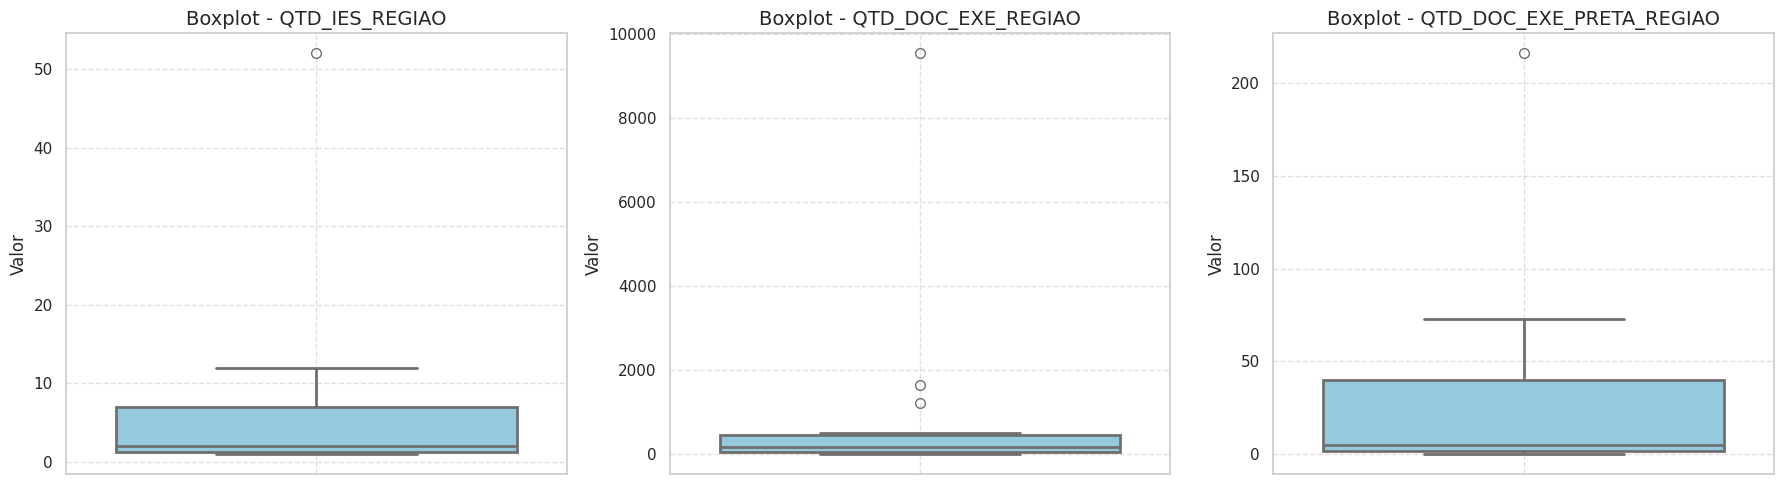

In [ ]:
# Garante que os gráficos sejam exibidos com estilo mais agradável
sns.set(style="whitegrid")

# Lista de colunas numéricas que serão analisadas
colunas_numericas = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']

# Define o tamanho da figura geral
plt.figure(figsize=(18, 5))

# Loop para gerar 1 boxplot por variável
for i, coluna in enumerate(colunas_numericas):
    plt.subplot(1, 3, i + 1)  # Cria subplots lado a lado
    sns.boxplot(data=df_resultado_regiao, y=coluna, color="skyblue", fliersize=7, linewidth=2)
    plt.title(f"Boxplot - {coluna}", fontsize=14)
    plt.ylabel('Valor')
    plt.xlabel('')  # Remove o eixo x (opcional)
    plt.grid(True, linestyle='--', alpha=0.6)

# Ajusta layout para não sobrepor textos
plt.tight_layout()
plt.show()


**Análise dos Gráficos**

QTD_IES_REGIAO:

*   A maioria das regiões possui até 7 instituições de ensino superior (IES), com a mediana próxima de 2. Grande Fortaleza é um outlier claro, com 52 IES, muito acima das demais regiões.

QTD_DOC_EXE_REGIAO

* A distribuição mostra grande variação entre as regiões, com muitos valores
concentrados abaixo de 500. Grande Fortaleza novamente se destaca como outlier, com quase 10 mil docentes, superando muito o restante.

QTD_DOC_EXE_PRETA_REGIAO

* A maioria das regiões tem menos de 10 docentes autodeclarados pretos, indicando baixa representatividade. Maciço de Baturité e especialmente Grande Fortaleza aparecem como outliers, com 73 e 216 docentes pretos, respectivamente.



## Estatística Descritiva

A estatística abaixo tomará como base o dataframe resultado (df_resultado), com as variáveis geradas por região de planejamento, que é o foco da pesquisa.
<br>



In [ ]:
# Estatística descritiva das colunas numéricas
print("\nEstatística descritiva das métricas por região:\n")
print(df_resultado_regiao.describe().round(2))



Estatística descritiva das métricas por região:

       QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
count           14.00               14.00                     14.00
mean             7.21             1000.64                     30.93
std             13.31             2505.34                     58.44
min              1.00                0.00                      0.00
25%              1.25               45.75                      1.50
50%              2.00              160.50                      5.00
75%              7.00              456.00                     40.00
max             52.00             9539.00                    216.00


### Análise dos Dados Estatísticos

**Quantidade de Instituições por Região (QTD_IES_REGIAO)**


A distribuição das Instituições de Ensino Superior (IES) entre as regiões analisadas é bastante desigual. Enquanto a **média geral** é de pouco mais de 7 instituições por região, a maioria delas possui apenas 1 ou 2 IES, como mostra a **mediana**. Por outro lado, uma única região concentra 52 instituições, evidenciando uma concentração significativa em locais específicos. Essa diferença é confirmada pelo **desvio padrão** elevado (13.3), que indica uma grande variação entre as regiões. Isso mostra que o acesso ao ensino superior pode estar muito limitado em diversas partes do território.

<br>

**Quantidade de Docentes em Exercício por Região (QT_DOC_EXE_REGIAO)**

Da mesma forma, a quantidade de docentes em exercício por região também apresenta um padrão de concentração. Apesar da **média** ser de cerca de 1.000 docentes por região, a **mediana** revela que metade das regiões tem menos de 160 docentes. Em contrapartida, uma região concentra mais de 9.500 docentes. Além disso, algumas regiões não têm nenhum docente registrado. Isso reverbera em um **desvio padrão** bastante elevado (2505.34), indicando uma grande variação entre as regiões. Essa distribuição desigual sugere que a oferta de professores também está fortemente centralizada, o que pode impactar diretamente a qualidade e o alcance da educação superior.

<br>

**Quantidade de Docentes Declarados Pretos por Região (QT_DOC_EX_PRETA_REGIAO)**

Quando analisamos a presença de docentes pretos por região, a desigualdade é ainda mais evidente. Enquanto a **média** é de 30 docentes pretos por região, metade das regiões têm apenas 5 ou menos, e algumas não possuem nenhum. A maior concentração está em uma única região com 216 docentes pretos. O alto **desvio padrão** reforça essa disparidade. Esses dados apontam para uma sub-representação racial significativa em grande parte do território, o que pode estar ligado a barreiras estruturais de acesso e permanência de profissionais pretos no ensino superior.


### Histogramas com Curva de Densidade da Estatística Descritiva

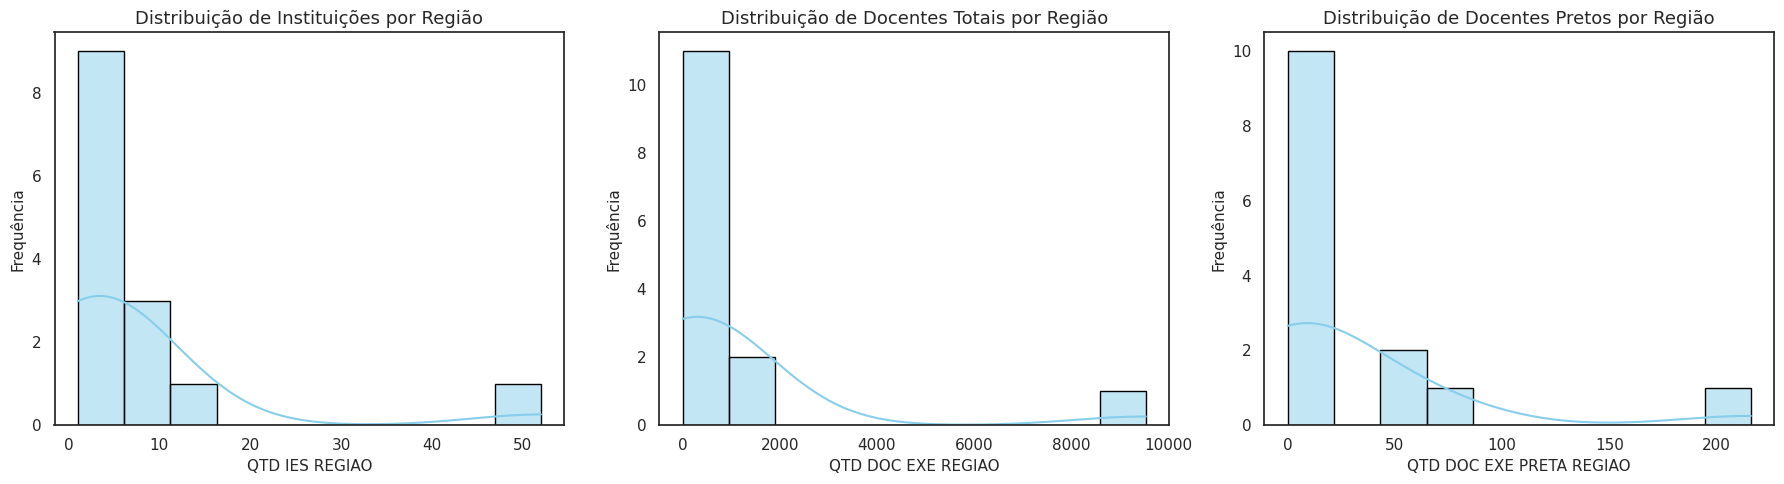

In [ ]:
# Configurar estilo sem grid
sns.set_style("white")

# Lista de variáveis e títulos
variaveis = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']
titulos = [
    'Distribuição de Instituições por Região',
    'Distribuição de Docentes Totais por Região',
    'Distribuição de Docentes Pretos por Região'
]

# Criar subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variaveis):
    sns.histplot(
        data=df_resultado_regiao,
        x=var,
        kde=True,
        ax=axes[i],
        color='skyblue',
        edgecolor='black',
        bins=10
    )
    axes[i].set_title(titulos[i], fontsize=13)
    axes[i].set_xlabel(var.replace('_', ' '), fontsize=11)
    axes[i].set_ylabel('Frequência', fontsize=11)
    axes[i].grid(False)

plt.tight_layout()
plt.show()



### Análise dos gráficos de histograma


**QTD_IES_REGIAO (Instituições por Região)**

A distribuição é assimétrica à direita, com poucas regiões concentrando a maioria das IES. A maioria das regiões possui entre 1 e 7 instituições, com um pico extremo (outlier) próximo de 52.

**QTD_DOC_EXE_REGIAO (Docentes Totais por Região)**

A curva mostra uma grande assimetria, indicando que poucas regiões concentram a maior parte dos docentes. A maior parte das regiões possui menos de 500 docentes, enquanto uma delas ultrapassa os 9 mil.

**QTD_DOC_EXE_PRETA_REGIAO (Docentes Pretos por Região)**

A distribuição é bastante concentrada perto de zero, refletindo sub-representação em muitas regiões. Há poucos casos com quantidades elevadas, revelando desigualdade marcante na composição racial dos docentes.

### Matriz de Correlação entre Métricas por Região

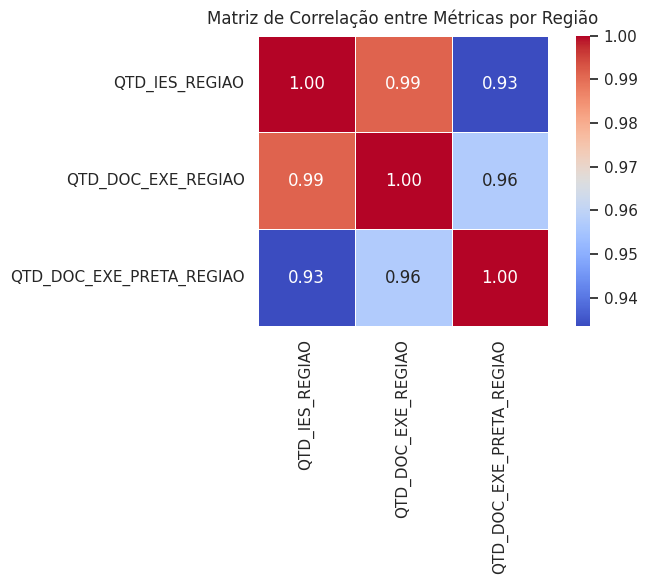

In [ ]:
# Seleciona apenas as colunas numéricas desejadas
colunas = ["QTD_IES_REGIAO", "QTD_DOC_EXE_REGIAO", "QTD_DOC_EXE_PRETA_REGIAO"]
df_corr = df_resultado_regiao[colunas]

# Criação do gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

# Título e exibição
plt.title('Matriz de Correlação entre Métricas por Região', fontsize=12, pad=8)
plt.tight_layout()
plt.show()



### Análise do Gráfico de Matriz de Correlação


**A correlação entre QTD_DOC_EXE_REGIAO e QTD_DOC_EXE_PRETA_REGIAO é fortemente positiva** (valor próximo de 1), representada no gráfico por uma cor vermelha intensa, indicando que regiões com mais docentes em geral também concentram mais docentes pretos.

**A correlação entre QTD_IES_REGIAO e QTD_DOC_EXE_REGIAO é moderada e positiva**, vista por um tom laranja ou vermelho claro, sugerindo que mais instituições atraem mais docentes.

**Já a correlação entre QTD_IES_REGIAO e QTD_DOC_EXE_PRETA_REGIAO é mais fraca** (cor mais clara ou esbranquiçada), mostrando que o número de instituições não se relaciona fortemente com a presença de docentes pretos, apontando para uma possível desigualdade de distribuição.

Em resumo, apesar de regiões com mais docentes em geral também concentrarem mais docentes pretos, a presença de docentes pretos não cresce na mesma proporção que o número de instituições, o que indica que a distribuição racial entre docentes não acompanha o crescimento institucional — ou seja, não basta haver mais IES em uma região para que haja maior inclusão racial.

**Portanto, há sinais de desigualdade na distribuição de docentes pretos entre as regiões, sugerindo a necessidade de políticas específicas de equidade racial no corpo docente, além da simples expansão institucional.**



#PRÉ-PROCESSAMENTO DE DADOS


## Análise Exploratória e Clusterização

Durante o processo de análise exploratória e descritiva, foi possível levantar hipóteses relevantes sobre a distribuição das Instituições de Ensino Superior (IES) e dos docentes autodeclarados pretos nessas instituições. Embora o dataset não apresentasse uma variável-alvo adequada para modelagem preditiva, optou-se por aplicar técnicas de aprendizado não supervisionado — modelos de clusterização — com o objetivo de identificar padrões e agrupamentos latentes entre as Regiões de Planejamento. Essa abordagem está alinhada com uma análise diagnóstica, voltada à compreensão estrutural do fenômeno estudado.

## Normalização

Com base na análise estatística e gráficos anteriores do dataframe df_resultado_regiao, percebemos que as escalas das variáveis são muito diferentes. A variável QTD_DOC_EXE_REGIAO, por exemplo, varia de 0 a 9539, enquanto QTD_IES_REGIAO varia apenas de 1 a 52. Isso pode distorcer análises comparativas, visuais ou estatísticas. Para poder comparar as variáveis de forma mais equilibrada, principalmente ao construir gráficos ou aplicar algoritmos de machine learning, os dados serão normalziados.




In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Copiar os dados originais
df_normalizado = df_resultado_regiao.copy()

# Selecionar as colunas a normalizar
colunas = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']

# Aplicar normalização Min-Max
scaler = MinMaxScaler()
df_normalizado[colunas] = scaler.fit_transform(df_normalizado[colunas])

# Exibir dados normalizados
print(df_normalizado)


                          Regiao  QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
0                         Cariri        0.215686            0.171297                  0.254630
1                     Centro Sul        0.058824            0.024216                  0.046296
2               Grande Fortaleza        1.000000            1.000000                  1.000000
3                  Litoral Leste        0.000000            0.009435                  0.013889
4                  Litoral Norte        0.000000            0.001468                  0.004630
5   Litoral Oeste / Vale do Curu        0.000000            0.000000                  0.000000
6             Maciço de Baturité        0.019608            0.051473                  0.337963
7              Serra da Ibiapaba        0.117647            0.036796                  0.046296
8                 Sertão Central        0.117647            0.027571                  0.027778
9              Sertão de Canindé        0.019608  

**Análise**: Antes da normalização, as variáveis tinham escalas muito diferentes, variando de 1 a 9539, o que distorce comparações diretas. Após a normalização, todas as variáveis foram reescaladas para o intervalo entre 0 e 1, permitindo comparações justas e proporcionais.

# MODELAGEM E TREINAMENTO **(*Sprint Machine Learning e Analitics*)**

O contexto desta pesquisa apontou um evidente desequilíbrio entre a distribuição de instituições de ensino e de docentes pretos por região do estado do Ceará. Como explicado anteriormente, este dataset não se adequa a uma modelagem preditiva, uma vez que sua análise exploratória e descritiva é suficiente para explorar as hpóteses levantadas, além de não ter uma variável-alvo com características adequadas para predição em modelos supervisionados.

No entanto, observou-se ser relevante a construção de um modelo de clusterização para agrupar regiões com características semelhantes, sem a necessidade de rótulos pré-existentes, o qual permitirá descobrir padrões ocultos não identificados sem a clusterização, segmentando regiões com base em suas realidades educacionais diversas e ampliando as possibilidades de políticas públicas melhor direcionadas.

Para tanto, serão selecionados os algoritmos **K-Means**, adequado para variáveis contínuas e dados normalizados, que é o caso; e o **Agglomerative Clustering (Hierárquico)**, o qual não exige pré-definir o número de clusters e irá permitir capturar relações hierárquicas entre regiões, o que pode ser muito útil em contextos de políticas públicas regionais. Em seguida, os resultados dos modelos serão comparados para avaliar qual deles melhor agrupa as regiões com base em seus perfis educacionais, considerando fatores como coesão interna dos clusters, separação entre grupos e interpretabilidade.

Ressalta-se que, como em modelos de clusterização (não supervisionados) não há divisão entre treino e teste, o ajuste de hiperparâmetros é parte do processo de descoberta dos padrões, sendo esse ajuste o próprio teste do modelo, que irá avaliar a formação de grupos em diferentes configurações.

## Ajuste de hiperparâmetros

Para ajustar os algoritmos K-Means e Agglomerative Clustering será selecionada e exibida no código abaixo a mesma técnica, **Silhouette Score**, adequada para conjuntos de dados esparsos, com muitas observações iguais a zero, situação do dataset trabalhado.

Será realizado um comparativo de resultados para os dois modelos, um com K-Means e outro com Agglomerative Clustering, em que será verificado o número de clusters gerados em cada um para decidir qual modelo é mais adequando.

Ressalta-se que, como o dataset em questão tem somente três variáveis, será usado o Principal Component Analysis (PCA) somente para o gráfico de dispersão, a fim de reduzir os dados para 2 dimensões para visualizar os clusters em um gráfico.

Silhouette Scores para diferentes valores de k:
k = 2: KMeans = 0.8354, Agglomerative = 0.8354
k = 3: KMeans = 0.6700, Agglomerative = 0.6700
k = 4: KMeans = 0.5903, Agglomerative = 0.6306
k = 5: KMeans = 0.5134, Agglomerative = 0.5747
Lista de regiões com os clusters atribuídos e Silhouette Scores (para k = 2):
                      Regiao  Cluster_KMeans  Silhouette_KMeans  Cluster_Agglomerative  Silhouette_Agglomerative
                      Cariri               0             0.8354                      0                    0.8354
                  Centro Sul               0             0.8354                      0                    0.8354
            Grande Fortaleza               1             0.8354                      1                    0.8354
               Litoral Leste               0             0.8354                      0                    0.8354
               Litoral Norte               0             0.8354                      0                    0.8354
Litoral 

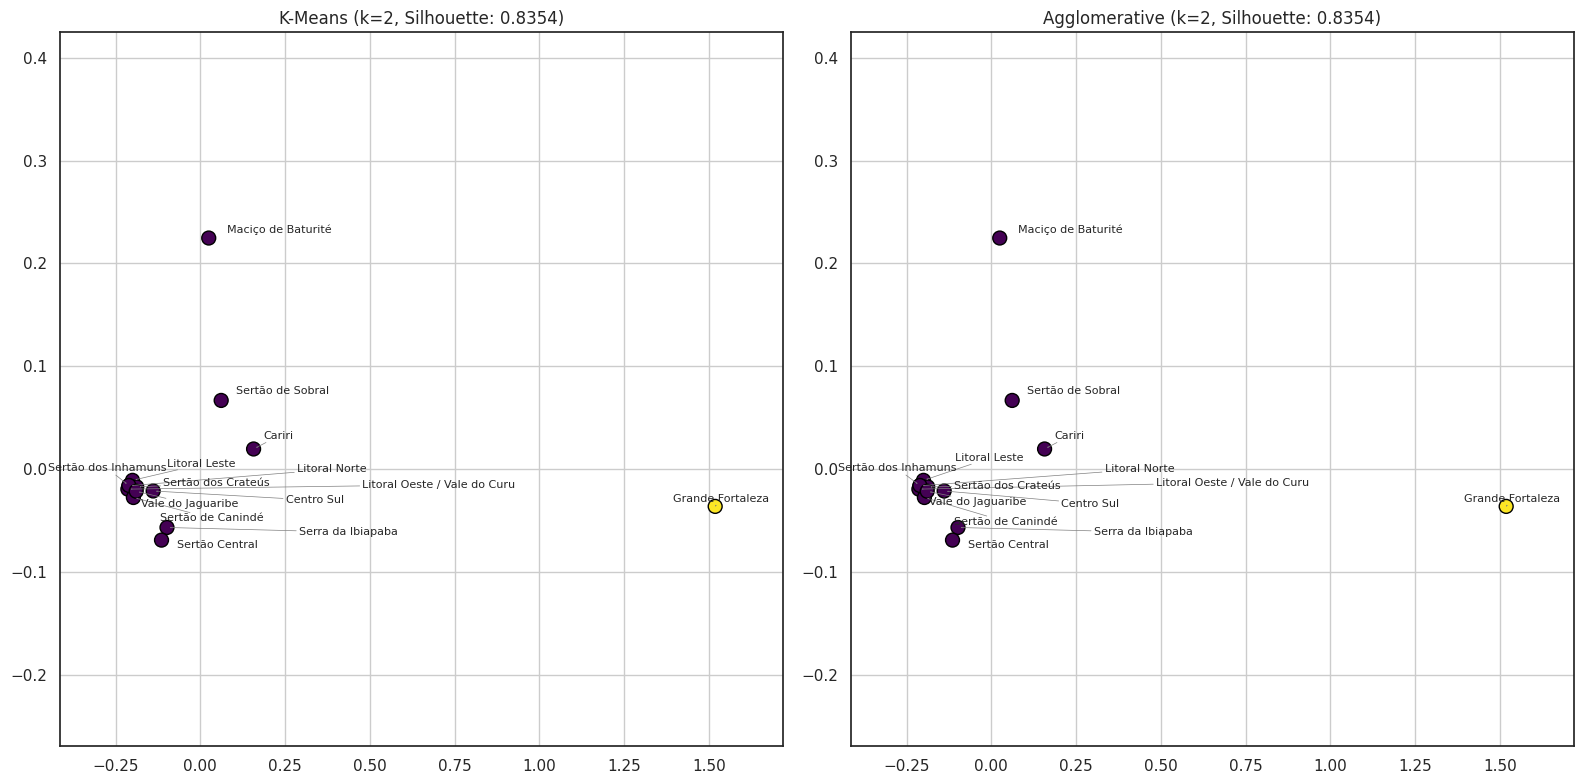

In [ ]:
# Dados normalizados
data = {
    "Regiao": [
        "Cariri", "Centro Sul", "Grande Fortaleza", "Litoral Leste", "Litoral Norte",
        "Litoral Oeste / Vale do Curu", "Maciço de Baturité", "Serra da Ibiapaba",
        "Sertão Central", "Sertão de Canindé", "Sertão de Sobral", "Sertão dos Crateús",
        "Sertão dos Inhamuns", "Vale do Jaguaribe"
    ],
    "QTD_IES_REGIAO": [
        0.215686, 0.058824, 1.0, 0.0, 0.0,
        0.0, 0.019608, 0.117647, 0.117647, 0.019608,
        0.117647, 0.019608, 0.0, 0.019608
    ],
    "QTD_DOC_EXE_REGIAO": [
        0.171297, 0.024216, 1.0, 0.009435, 0.001468,
        0.0, 0.051473, 0.036796, 0.027571, 0.004088,
        0.126009, 0.006919, 0.000419, 0.008911
    ],
    "QTD_DOC_EXE_PRETA_REGIAO": [
        0.25463, 0.046296, 1.0, 0.013889, 0.00463,
        0.0, 0.337963, 0.046296, 0.027778, 0.00463,
        0.231481, 0.018519, 0.00463, 0.013889
    ]
}

df = pd.DataFrame(data)
X = df.drop(columns=["Regiao"])

# Redução com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Avaliar Silhouette Score para diferentes valores de k
k_values = [2, 3, 4, 5]
scores = []

print("Silhouette Scores para diferentes valores de k:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')

    kmeans_labels = kmeans.fit_predict(X)
    agg_labels = agg.fit_predict(X)

    silhouette_kmeans = silhouette_score(X, kmeans_labels)
    silhouette_agg = silhouette_score(X, agg_labels)

    scores.append({
        "k": k,
        "Silhouette_KMeans": round(silhouette_kmeans, 4),
        "Silhouette_Agglomerative": round(silhouette_agg, 4)
    })

    print(f"k = {k}: KMeans = {silhouette_kmeans:.4f}, Agglomerative = {silhouette_agg:.4f}")


# Agora, mostrar os clusters e gráficos apenas para k=2
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')

df["Cluster_KMeans"] = kmeans.fit_predict(X)
df["Cluster_Agglomerative"] = agg.fit_predict(X)

silhouette_kmeans = silhouette_score(X, df["Cluster_KMeans"])
silhouette_agg = silhouette_score(X, df["Cluster_Agglomerative"])

df["Silhouette_KMeans"] = round(silhouette_kmeans, 4)
df["Silhouette_Agglomerative"] = round(silhouette_agg, 4)

# Exibir lista com clusters e silhouette score no console
print("Lista de regiões com os clusters atribuídos e Silhouette Scores (para k = 2):")
print(df[["Regiao", "Cluster_KMeans", "Silhouette_KMeans", "Cluster_Agglomerative", "Silhouette_Agglomerative"]].to_string(index=False))

# Função para plotar com adjustText
def plot_clusters(ax, X, labels, title):
    ax.set_xlim(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2)
    ax.set_ylim(X[:, 1].min() - 0.2, X[:, 1].max() + 0.2)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, edgecolor='black')
    texts = [ax.text(X[i, 0], X[i, 1], df["Regiao"][i], fontsize=8) for i in range(len(X))]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
    ax.set_title(title)
    ax.grid(True)

# Gráficos lado a lado
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_clusters(axs[0], X_pca, df["Cluster_KMeans"], f"K-Means (k=2, Silhouette: {silhouette_kmeans:.4f})")
plot_clusters(axs[1], X_pca, df["Cluster_Agglomerative"], f"Agglomerative (k=2, Silhouette: {silhouette_agg:.4f})")
plt.tight_layout()
plt.show()


**Análise Geral**

A análise de clusterização identificou dois grupos principais (K=2) como a melhor divisão dos dados, com um excelente Silhouette Score de 0.8354. O **Cluster 0** inclui 13 das 14 regiões do Ceará, caracterizadas por baixa concentração de instituições e docentes (inclusive pretos), refletindo o interior do estado. O **Cluster 1** inclui apenas a **Grande Fortaleza**, que se destaca como um **outlier** devido à sua alta densidade institucional e diversidade docente.

Ambos os métodos de clusterização utilizados (K-Means e Agglomerative Clustering) chegaram à mesma estrutura, validando o uso do K-Means, especialmente em datasets de baixa complexidade. A análise de componentes principais (PCA) mostrou que as variáveis relacionadas à quantidade de docentes pretos e instituições foram determinantes para a separação, reforçando o papel central da Grande Fortaleza no cenário educacional do estado.
<br> <br>

**Análise sobre Underfitting e otimização de hiperparâmetros**

Apesar de a técnica Silhouette Score ter indicado K igual a 2 como o melhor score para o agrupamento das 14 regiões em questão, o modelo só conseguiu perceber que "Grande Fortaleza" é diferente e tratou todas as outras 13 regiões como se fossem iguais, colocando-as no mesmo grupo — ainda que sejam regiões diferenças entre si. Desse modo, é possível que o modelo não tenha aprendido bem as particularidades das outras 13 regiões, já que as alocou todas juntas, ignorando detalhes e não representando bem a diversidade dos dados, ou seja, existe uma sub-representação da estrutura real do conjunto de dados, típico caso de underfitting.

É importante observar que se existe um ponto muito distante dos outros (como "Grande Fortaleza", o outlier), o algoritmo pode simplesmente separá-lo em um cluster e colocar todo o resto em outro, e o Silhouette Score será alto — mesmo que o modelo não tenha aprendido a estrutura real dos dados. Isso significa que o modelo está fazendo uma separação muito óbvia, simplificando demais e ignorando todas as outras variações menores dentro do segundo cluster. Isso pode significar que o Silhouette Score pode ser enganoso em casos com outliers ou dados muito desbalanceados. Portanto, é importante complementar essa análise quantitativa com uma análise qualitativa. Às vezes, um Silhouette Score um pouco menor (com k=3 ou k=4, por exemplo) pode gerar clusters mais interpretáveis e úteis. O objetivo não é só a métrica matemática, mas entender e representar bem os dados, identificando nuances importantes. **Em razão disso, o modelo será executado a seguir com um k igual a 3 para avaliarmos se esse ajuste trará mudanças relevantes. Vale acrescentar que para o modelo em questão, não supervisionado (agrupamento), esse tipo de ajuste pode ser considerado uma otimização de hiperparâmetro, uma vez que, não caberia aqui, por exemplo métricas de acurácia ou F1-score, adequadas em contextos de aprendizado supervsionado**






Lista de regiões com os clusters atribuídos e Silhouette Scores (para k = 3):
                      Regiao  Cluster_KMeans  Silhouette_KMeans  Cluster_Agglomerative  Silhouette_Agglomerative
                      Cariri               2               0.67                      0                      0.67
                  Centro Sul               0               0.67                      2                      0.67
            Grande Fortaleza               1               0.67                      1                      0.67
               Litoral Leste               0               0.67                      2                      0.67
               Litoral Norte               0               0.67                      2                      0.67
Litoral Oeste / Vale do Curu               0               0.67                      2                      0.67
          Maciço de Baturité               2               0.67                      0                      0.67
           Serra d

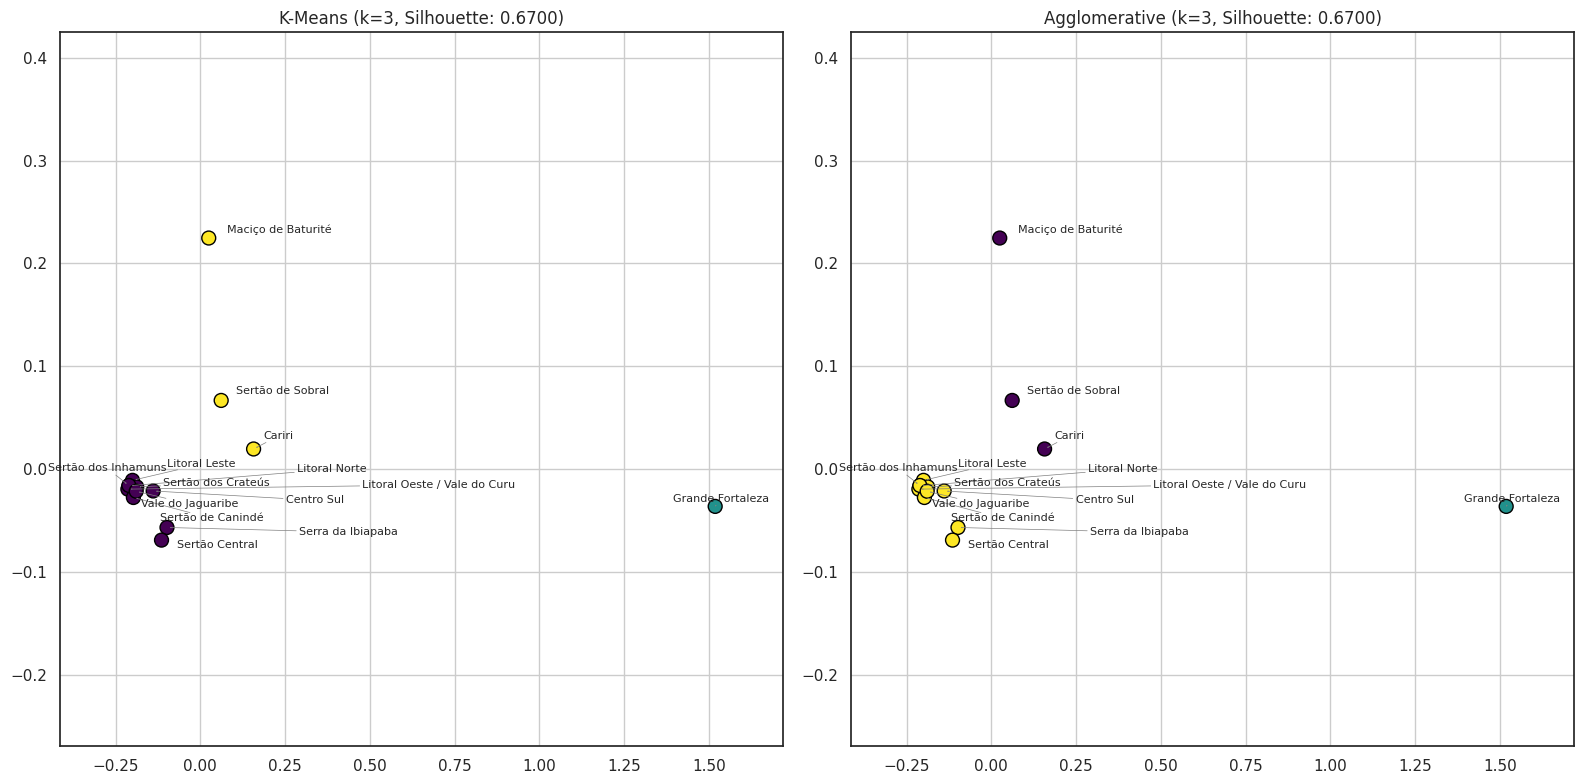

In [ ]:
# Agora, mostrar os clusters e gráficos apenas para k=3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')

df["Cluster_KMeans"] = kmeans.fit_predict(X)
df["Cluster_Agglomerative"] = agg.fit_predict(X)

silhouette_kmeans = silhouette_score(X, df["Cluster_KMeans"])
silhouette_agg = silhouette_score(X, df["Cluster_Agglomerative"])

df["Silhouette_KMeans"] = round(silhouette_kmeans, 4)
df["Silhouette_Agglomerative"] = round(silhouette_agg, 4)

# Exibir lista com clusters e silhouette score no console
print(f"Lista de regiões com os clusters atribuídos e Silhouette Scores (para k = {k}):")
print(df[["Regiao", "Cluster_KMeans", "Silhouette_KMeans", "Cluster_Agglomerative", "Silhouette_Agglomerative"]].to_string(index=False))

# Gráficos lado a lado
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_clusters(axs[0], X_pca, df["Cluster_KMeans"], f"K-Means (k={k}, Silhouette: {silhouette_kmeans:.4f})")
plot_clusters(axs[1], X_pca, df["Cluster_Agglomerative"], f"Agglomerative (k={k}, Silhouette: {silhouette_agg:.4f})")
plt.tight_layout()
plt.show()



**Análise**

A escolha do número de clusters no algoritmo K-Means foi conduzida como um processo de **otimização de hiperparâmetro**, utilizando o **Silhouette Score** como métrica interna de avaliação da qualidade da clusterização. Inicialmente, o modelo foi executado com k igual a 2 em razão desse valor ter obtido maior score (0.8354), tanto no algoritmo K-Means, quanto no  Agglomerative Clustering. Contudo, como explicado anteriormente, a configuração do modelo em apenas dois grupos revelou um *Underfitting.*

No entanto, a configuração com k igual a 3 também apresentou um Silhouette Score relativamente alto (0.67), o que motivou uma análise mais aprofundada dessa estrutura alternativa. Apesar da leve redução na métrica de desempenho, a configuração com três clusters revelou **novas nuances estruturais nos dados**. Especificamente, permitiu a distinção entre:

* Um cluster centralizado exclusivamente na Grande Fortaleza (**Cluster 1**, fortemente destacado por sua densidade institucional e diversidade de docentes);
* Um grupo formado por regiões interioranas com baixíssimos indicadores educacionais (**Cluster 0**); e
* E um terceiro grupo (**Cluster 2**) que agregou regiões com características intermediárias, como o Cariri, o Maciço de Baturité e o Sertão de Sobral — áreas com algum destaque em pelo menos uma das variáveis analisadas.

Essa abordagem revela um *trade-off* entre simplicidade e riqueza interpretativa: **enquanto k igual a 2 oferece uma separação mais robusta e coesa dos dados, k igual a 3 permite capturar melhor a heterogeneidade interna do interior do estado do Ceará.** Portanto, a experimentação com diferentes valores de `k` revelou-se uma forma válida e fundamentada de otimização de hiperparâmetros no contexto do método não supervisionado, realidade deste dataset.


##Validando o melhor K com Calinski-Harabasz

Para validar e reforçar se os clusters estão melhor dispersos entre si e coesos internamente com k igual a 3, utilizaremos uma métrica complementar ao Silhouette Score, o **Calinski-Harabasz**. Para este tipo de dados, que possuem baixa dimensionalidade (apenas três variáveis) e poucos pontos (14 regiões), o uso do índice de Calinski-Harabasz é mais apropriado quando se aplica um algoritmo como K-Means ou Agglomerative Clustering, pois ele ajuda a escolher o número ideal de clusters (k) ao medir a separação e a coesão entre os grupos. Evitou-se o DBSCAN, pois ele seria ineficaz nesse contexto, já depende fortemente dos parâmetros eps e min_samples, que são difíceis de ajustar corretamente em datasets pequenos e desbalanceados.

Calinski-Harabasz Index para diferentes valores de k:

k = 2 ➜ CH Index = 119.48
k = 3 ➜ CH Index = 259.42
k = 4 ➜ CH Index = 246.51
k = 5 ➜ CH Index = 361.58


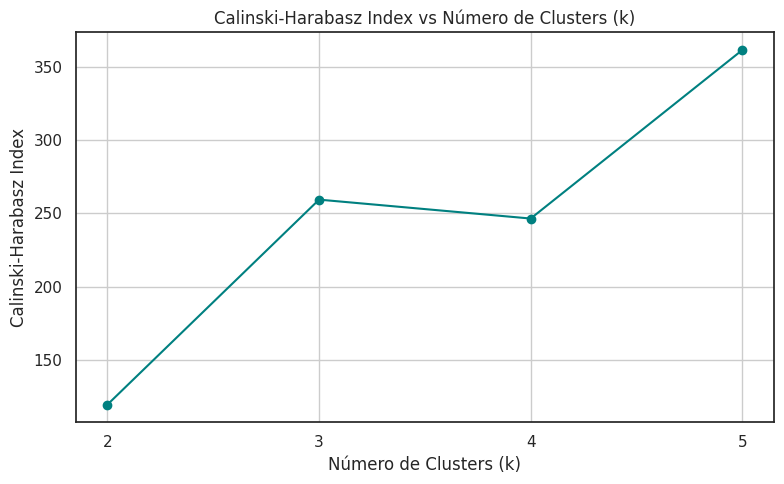

In [ ]:
# Selecionar os dados normalizados
X = df_normalizado[['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']]

# Faixa de valores de k a testar
k_values = [2, 3, 4, 5]
ch_scores = []

print("Calinski-Harabasz Index para diferentes valores de k:\n")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    ch_score = calinski_harabasz_score(X, labels)
    ch_scores.append((k, ch_score))
    print(f"k = {k} ➜ CH Index = {ch_score:.2f}")

# Separar valores de k e scores para plotagem
ks, scores = zip(*ch_scores)

# Gerar o gráfico
plt.figure(figsize=(8, 5))
plt.plot(ks, scores, marker='o', linestyle='-', color='teal')
plt.title('Calinski-Harabasz Index vs Número de Clusters (k)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Calinski-Harabasz Index')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()



**Análise**

O maior valor do CH Index foi com k = 5 (361.58) → isso indica que, matematicamente, essa configuração gerou os clusters mais bem separados e compactos.

O valor com k = 3 (259.42) também foi significativamente maior que o de k = 2 (119.48), o que reforça a observação anterior: com k = 3, a estrutura de grupos melhora não só interpretativamente, mas também estatisticamente.

O índice diminui um pouco em k = 4, o que pode indicar que os clusters ficaram mais “confusos” ou redundantes.

k = 2 ➜ Embora tenha bom Silhouette Score, o CH Index é bem mais baixo → clusters muito desbalanceados, como Fortaleza vs o resto do estado.

k = 3 ➜ Traz mais nuances nos dados e já tem um CH Index muito melhor → ótimo ponto de equilíbrio entre qualidade matemática e interpretabilidade.

k = 5 ➜ Melhor separação estatística, mas pode resultar em clusters difíceis de interpretar, ou dividir grupos muito similares.

O Calinski-Harabasz Index confirma que k igual a 3 é melhor que k igual a 2, pois melhora a separação dos grupos.

Há também o k igual a 5, que seria matematicamente o mais “eficiente”, mas com pouco sentido interpretativo, já que traria um agrupamento muito fragmentado, com pouca utilidade prática.



##Ensemble Heterogêneo

Após a aplicação das técnicas K-Means, Agglomerative Clustering e avaliação pelo índice de Calinski-Harabasz, será aplicado o *ensemble clustering* com vistas a  integrar os pontos fortes de cada abordagem e tentar alcançar uma segmentação mais robusta e representativa das regiões.


### Executando o Ensemble com Mode Voting

Clusters atribuídos e Silhouette Scores (k = 3):
                      Regiao  Cluster_KMeans  Cluster_Agglomerative  Cluster_Ensemble
                      Cariri               2                      0                 0
                  Centro Sul               0                      2                 0
            Grande Fortaleza               1                      1                 1
               Litoral Leste               0                      2                 0
               Litoral Norte               0                      2                 0
Litoral Oeste / Vale do Curu               0                      2                 0
          Maciço de Baturité               2                      0                 0
           Serra da Ibiapaba               0                      2                 0
              Sertão Central               0                      2                 0
           Sertão de Canindé               0                      2                 0
     

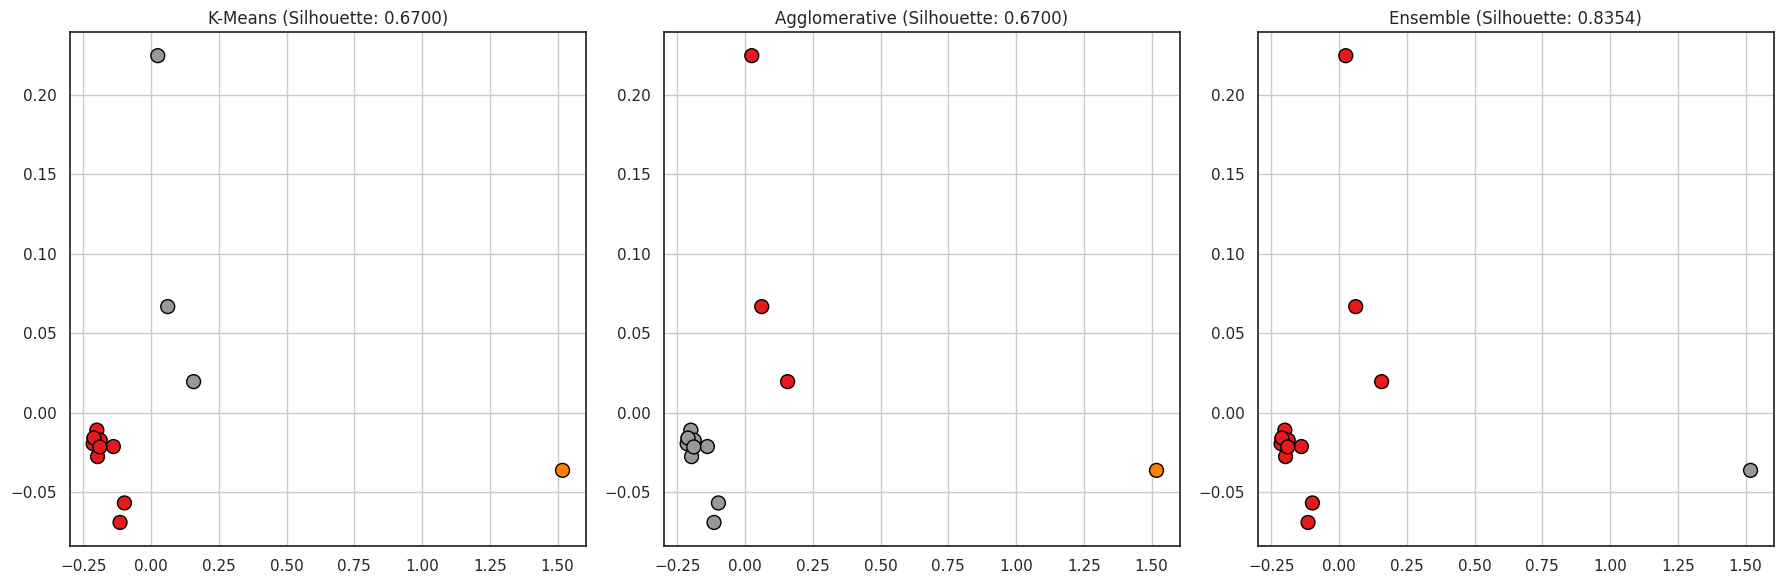

In [ ]:
# Selecionar colunas para clusterização
X = df_normalizado[['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']]

# Redução de dimensionalidade para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Definir número de clusters com base na análise anterior
k = 3

# Aplicar KMeans e Agglomerative
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')

df["Cluster_KMeans"] = kmeans.fit_predict(X)
df["Cluster_Agglomerative"] = agg.fit_predict(X)

# Avaliação com Silhouette Score
silhouette_kmeans = silhouette_score(X, df["Cluster_KMeans"])
silhouette_agg = silhouette_score(X, df["Cluster_Agglomerative"])

# Avaliação com Calinski-Harabasz Index
ch_kmeans = calinski_harabasz_score(X, df["Cluster_KMeans"])
ch_agg = calinski_harabasz_score(X, df["Cluster_Agglomerative"])

# Ensemble por votação entre KMeans e Agglomerative
def ensemble_vote(row):
    clusters = [row['Cluster_KMeans'], row['Cluster_Agglomerative']]
    return int(mode(clusters, keepdims=True)[0][0])

df["Cluster_Ensemble"] = df.apply(ensemble_vote, axis=1)

# Avaliação do ensemble
silhouette_ensemble = silhouette_score(X, df["Cluster_Ensemble"])

# Exibir resultados
print(f"Clusters atribuídos e Silhouette Scores (k = {k}):")
print(df[["Regiao", "Cluster_KMeans", "Cluster_Agglomerative", "Cluster_Ensemble"]].to_string(index=False))

print(f"Silhouette Scores:")
print(f"   - KMeans:        {silhouette_kmeans:.4f}")
print(f"   - Agglomerative: {silhouette_agg:.4f}")
print(f"   - Ensemble:      {silhouette_ensemble:.4f}")

print(f"Calinski-Harabasz Index:")
print(f"   - KMeans:        {ch_kmeans:.2f}")
print(f"   - Agglomerative: {ch_agg:.2f}")

#Visualização dos clusters
def plot_clusters(ax, data, labels, title):
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1', s=100, edgecolor='black')
    ax.set_title(title)
    ax.grid(True)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plot_clusters(axs[0], X_pca, df["Cluster_KMeans"], f"K-Means (Silhouette: {silhouette_kmeans:.4f})")
plot_clusters(axs[1], X_pca, df["Cluster_Agglomerative"], f"Agglomerative (Silhouette: {silhouette_agg:.4f})")
plot_clusters(axs[2], X_pca, df["Cluster_Ensemble"], f"Ensemble (Silhouette: {silhouette_ensemble:.4f})")

plt.tight_layout()
plt.show()



**Análise**

O ensemble combinou os resultados dos algoritmos K-Means e Agglomerative Clustering por **Mode Voting**, onde a maioria define o cluster final. Ambos coincidiram ao isolar "Grande Fortaleza" em um cluster exclusivo (1), enquanto as demais regiões foram agrupadas principalmente no cluster 0. Isso resultou em um modelo coeso, com boa separação entre grupos e destaque para a única região significativamente distinta.

O Silhouette Score do ensemble foi 0.8354, superior ao dos modelos individuais (ambos com 0.6700), indicando clusters mais bem separados e compactos. Embora o Calinski-Harabasz Index tenha sido igual nos dois algoritmos base (259.42), não se aplica diretamente ao ensemble, mas o ganho no Silhouette já comprova a melhoria na clusterização.

O ensemble produziu essencialmente dois grupos: um com "Grande Fortaleza", devido ao seu perfil muito distinto (outlier), e outro com todas as demais regiões, tratadas como homogêneas. Apesar do alto Silhouette Score, o modelo não capturou nuances entre as outras regiões, que possuem perfis variados.

Na execução com k=3, os algoritmos base criaram: 1 cluster isolado para "Grande Fortaleza", 1 cluster com a maioria das regiões e 1 cluster pequeno, mal utilizado. Na prática, o ensemble resultou em dois grupos efetivos, pois o terceiro cluster foi absorvido ou esvaziado, mostrando que o modelo foi influenciado demais por um único ponto distinto.

Portanto, o ensemble atual destaca corretamente o outlier, mas falha em representar a diversidade entre as demais regiões. **Para melhorar, iremos rodar novamente o modelo abaixo, mas agora com a técnica  Co-association Matrix.**

###Executando o Ensemble com Co-association Matrix


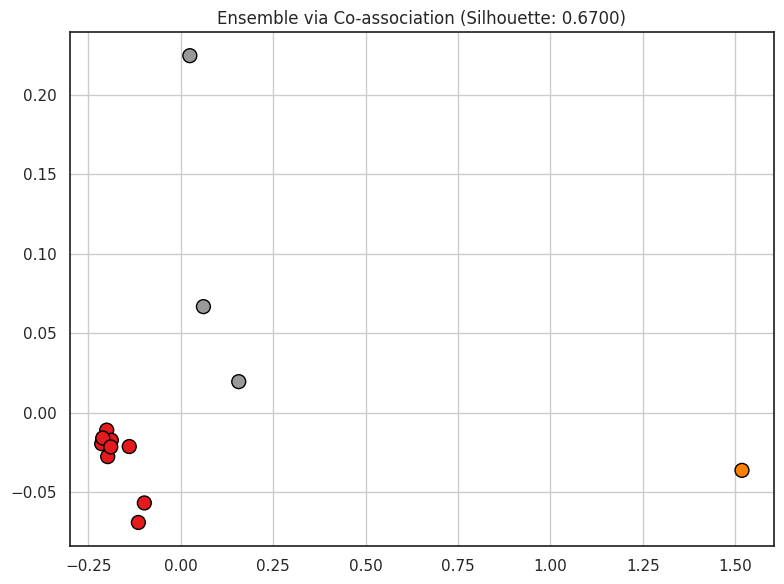

Cluster final via Co-association Matrix:
                      Regiao  Cluster_Ensemble_Coassoc
                      Cariri                         2
                  Centro Sul                         0
            Grande Fortaleza                         1
               Litoral Leste                         0
               Litoral Norte                         0
Litoral Oeste / Vale do Curu                         0
          Maciço de Baturité                         2
           Serra da Ibiapaba                         0
              Sertão Central                         0
           Sertão de Canindé                         0
            Sertão de Sobral                         2
          Sertão dos Crateús                         0
         Sertão dos Inhamuns                         0
           Vale do Jaguaribe                         0


In [ ]:
# Etapa 1: Dados
X = df_normalizado[['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']]
n = X.shape[0]
k = 3

# Etapa 2: Aplicar os algoritmos
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X)
dbscan = DBSCAN(eps=0.25, min_samples=2).fit(X)

# Armazenar rótulos
labels_list = [
    kmeans.labels_,
    agg.labels_,
    dbscan.labels_
]

# Etapa 3: Construir a co-association matrix
coassoc_matrix = np.zeros((n, n))

for labels in labels_list:
    for i in range(n):
        for j in range(n):
            # Se estiverem no mesmo cluster e não forem outliers
            if labels[i] != -1 and labels[j] != -1 and labels[i] == labels[j]:
                coassoc_matrix[i, j] += 1

# Etapa 4: Normalizar pela quantidade de algoritmos
coassoc_matrix /= len(labels_list)

# Etapa 5: Clustering final (Agglomerative sobre a co-association)
ensemble_model = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
df['Cluster_Ensemble_Coassoc'] = ensemble_model.fit_predict(1 - coassoc_matrix)

# Etapa 6: Avaliação
silhouette_ensemble = silhouette_score(X, df['Cluster_Ensemble_Coassoc'])

# Etapa 7: PCA para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Etapa 8: Visualização
def plot_clusters(ax, data, labels, title):
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1', s=100, edgecolor='black')
    ax.set_title(title)
    ax.grid(True)

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(ax, X_pca, df['Cluster_Ensemble_Coassoc'],
              f'Ensemble via Co-association (Silhouette: {silhouette_ensemble:.4f})')
plt.tight_layout()
plt.show()

# Etapa 9: Mostrar resultados
print(f"Cluster final via Co-association Matrix:")
print(df[["Regiao", "Cluster_Ensemble_Coassoc"]].to_string(index=False))


**Análise comparativa - Mode Voting x Co-association Matrix**


Diferente do Mode Voting, que colapsou quase todas as regiões em um único grupo, a Co-association Matrix conseguiu distinguir um subgrupo intermediário com perfil próprio, o que demonstra maior sensibilidade às diferenças regionais. Essa abordagem é mais robusta, pois leva em conta a frequência de coocorrência entre regiões em diferentes algoritmos, ao invés de apenas aplicar uma votação direta.

O resultado do Co-association Matrix com k = 3 mostra três clusters distintos, com a maioria das regiões agrupadas no cluster 0, indicando uma similaridade geral entre elas. Regiões como Cariri, Maciço de Baturité e Sertão de Sobral formam um grupo separado (cluster 2), sugerindo características específicas que as diferenciam das demais. Já Grande Fortaleza está isolada no cluster 1, refletindo seu perfil único e reforçando a necessidade de políticas públicas específicas para essa região.

Embora o Silhouette Score de 0.6700 indique uma separação moderada entre os grupos, o método revela nuances importantes que modelos mais simples, como o Mode Voting, podem não captar. Isso mostra que a Co-association Matrix é eficaz para detectar subgrupos regionais relevantes mesmo com poucos dados — algo crucial para o planejamento público.

No entanto, apesar de o Co-association Matrix ter trazido mais nuances que o Mode Voting, o cluster 0 ainda concentra 10 regiões, o que indica que a granularidade da análise ainda está limitada. Por isso, é válido rodar o ensemble novamente, agora com k igual 4. Pode tratar-se de uma boa estratégia, pois forçará os algoritmos a explorarem novas divisões dentro desse grupo dominante, possibilitando descobrir subgrupos com perfis distintos e permitindo políticas mais direcionadas e eficazes.


###Executando o Ensemble com Co-association Matrix para k igual a 4

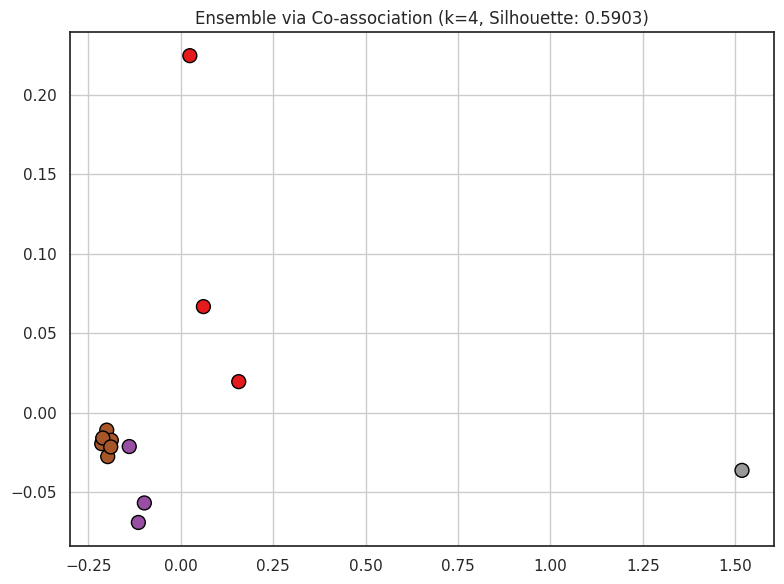

Cluster final via Co-association Matrix (k = 4):
                      Regiao  Cluster_Ensemble_Coassoc
                      Cariri                         0
                  Centro Sul                         1
            Grande Fortaleza                         3
               Litoral Leste                         2
               Litoral Norte                         2
Litoral Oeste / Vale do Curu                         2
          Maciço de Baturité                         0
           Serra da Ibiapaba                         1
              Sertão Central                         1
           Sertão de Canindé                         2
            Sertão de Sobral                         0
          Sertão dos Crateús                         2
         Sertão dos Inhamuns                         2
           Vale do Jaguaribe                         2
Silhouette Score do ensemble (k = 4): 0.5903


In [ ]:
# Etapa 1: Dados
X = df_normalizado[['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']]
n = X.shape[0]
k = 4

# Etapa 2: Aplicar os algoritmos base
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X)
dbscan = DBSCAN(eps=0.25, min_samples=2).fit(X)

# Armazenar rótulos
labels_list = [
    kmeans.labels_,
    agg.labels_,
    dbscan.labels_
]

# Etapa 3: Construir a co-association matrix
coassoc_matrix = np.zeros((n, n))

for labels in labels_list:
    for i in range(n):
        for j in range(n):
            # Se estiverem no mesmo cluster e não forem outliers
            if labels[i] != -1 and labels[j] != -1 and labels[i] == labels[j]:
                coassoc_matrix[i, j] += 1

# Etapa 4: Normalizar pela quantidade de algoritmos
coassoc_matrix /= len(labels_list)

# Etapa 5: Clustering final (Agglomerative sobre a co-association matrix)
ensemble_model = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
df['Cluster_Ensemble_Coassoc'] = ensemble_model.fit_predict(1 - coassoc_matrix)  # distância = 1 - similaridade

# Etapa 6: Avaliação
silhouette_ensemble = silhouette_score(X, df['Cluster_Ensemble_Coassoc'])

# Etapa 7: PCA para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Etapa 8: Visualização
def plot_clusters(ax, data, labels, title):
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1', s=100, edgecolor='black')
    ax.set_title(title)
    ax.grid(True)

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(ax, X_pca, df['Cluster_Ensemble_Coassoc'],
              f'Ensemble via Co-association (k={k}, Silhouette: {silhouette_ensemble:.4f})')
plt.tight_layout()
plt.show()

# Etapa 9: Mostrar resultados
print(f"Cluster final via Co-association Matrix (k = {k}):")
print(df[["Regiao", "Cluster_Ensemble_Coassoc"]].to_string(index=False))
print(f"Silhouette Score do ensemble (k = {k}): {silhouette_ensemble:.4f}")


**Análise**

**O ensemble com Co-association Matrix com k igual a 4 distribuiu melhor as 14 regiões, criando 4 grupos mais distintos:**

**Cluster 0:** Cariri, Maciço de Baturité, Sertão de Sobral
→ Essas regiões parecem compartilhar um perfil intermediário, com alguma presença institucional (IES/docentes), mas não no mesmo nível da capital. Formam um grupo com características socioeducacionais potencialmente semelhantes.

**Cluster 1:** Centro Sul, Serra da Ibiapaba, Sertão Central
→ Região mais interiorana e homogênea, com baixa densidade institucional. Esse grupo pode demandar políticas de expansão educacional e inclusão social mais robustas.

**Cluster 2:** Litoral Leste, Litoral Norte, Litoral Oeste / Vale do Curu, Sertão de Canindé, Crateús, Inhamuns, Vale do Jaguaribe
→ Um grupo heterogêneo geograficamente, mas que parece se alinhar nos dados com baixíssimos indicadores, podendo ser considerado o grupo mais vulnerável e prioritário.

**Cluster 3:** Grande Fortaleza
→ Continua isolada, como esperado, refletindo sua singularidade e concentração de recursos. Políticas públicas aqui precisam ser diferenciadas, com foco em gestão e equidade, não expansão.

* Sobre o Silhouette Score (0.5903)

Embora menor que o resultado com k = 3 (0.6700), o novo agrupamento oferece melhor granularidade e revela subgrupos antes ocultos no cluster dominante. Isso é esperado: quanto maior o número de clusters, menor tende a ser o Silhouette, mas maior o detalhamento da segmentação — o que é desejável para políticas públicas mais precisas.

# Conclusão

Com base em todas as etapas aplicadas, o melhor modelo para o objetivo proposto foi o *ensemble* via **Co-association Matrix com k igual a 4**. Ele foi capaz de segmentar as 14 regiões do Ceará em quatro grupos significativos, destacando não apenas a Grande Fortaleza como *outlier*, mas também criando subgrupos antes invisíveis com k igual a 3 ou no *Mode Voting*. Essa abordagem revelou nuances essenciais entre regiões interioranas, litorâneas e com níveis distintos de presença institucional.

O ensemble com Co-association Matrix com k igual a 4 distribuiu melhor as 14 regiões, criando quatro grupos mais distintos: **Cluster 0**: Cariri, Maciço de Baturité e Sertão de Sobral; **Cluster 1**: Centro Sul, Serra da Ibiapaba e Sertão Central; **Cluster 2**: Litoral Leste, Litoral Norte, Litoral Oeste, Vale do Curu, Sertão de Canindé, Crateús, Inhamuns e Vale do Jaguaribe; e **Cluster 3**: Grande Fortaleza.

Enquanto o *ensemble* com *Mode Voting* apresentou alto *Silhouette Score* (0.8354), ele agrupou quase todas as regiões no mesmo cluster, o que oculta variações importantes entre elas. Já aplicando o *Co-association Matrix* com k igual a 3, o modelo melhorou a sensibilidade, mas ainda manteve 10 regiões em um único grupo. Por outro lado, ao executar novamente o modelo Co-association Matrix ajustando para **k igual a 4**, foi possível identificar padrões específicos entre regiões médias e vulneráveis, possibilitando políticas públicas mais direcionadas e realistas.

Portanto, **a abordagem com Co-association Matrix com k igual a 4 é a mais adequada, pois equilibra bem a coerência estatística com a utilidade prática.** Mesmo com um *Silhouette Score* um pouco menor (0.5903), o ganho em granularidade supera essa queda. Isso é fundamental para desenvolver estratégias de distribuição de IES, aumento de docentes e valorização de docentes pretos de forma mais direcionada, conforme as características regionais.

Por fim, vale mencionar que não houve *overfitting* nos modelos executados, pois os modelos de clusterização não preveem rótulos, mas, sim, buscam identificar padrões estruturais nos dados. Além disso, o aumento no número de clusters foi gradual e justificado, não forçando separações artificiais, mas revelando realidades relevantes.
